<a href="https://colab.research.google.com/github/tselane2110/Agentic-AI-Assignment/blob/main/Pakistan_Climate_MultiAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [1]:
!pip install -q transformers torch numpy matplotlib pandas seaborn psutil accelerate huggingface_hub

In [2]:
import time
import warnings
from dataclasses import dataclass, field
from typing import List, Dict, Tuple
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Libraries loaded.')

Libraries loaded.


## Climate Dataset

In [3]:


years = np.arange(1990, 2026)

co2_real = {
    1990: 87918,  1991: 91168,  1992: 96096,  1993: 97207,  1994: 100761,
    1995: 104915, 1996: 109169, 1997: 111468, 1998: 113411, 1999: 110692,
    2000: 113063, 2001: 114870, 2002: 116767, 2003: 120516, 2004: 130111,
    2005: 141432, 2006: 152022, 2007: 158905, 2008: 163001, 2009: 161178,
    2010: 163752, 2011: 166304, 2012: 169567, 2013: 175434, 2014: 178345,
    2015: 183211, 2016: 191023, 2017: 200134, 2018: 211045, 2019: 215678,
    2020: 198432, 2021: 210987, 2022: 223456,
}

temp_real = {
    1990: 22.1, 1991: 22.0, 1992: 22.3, 1993: 22.1, 1994: 22.4,
    1995: 22.2, 1996: 22.5, 1997: 22.3, 1998: 22.8, 1999: 22.6,
    2000: 22.7, 2001: 22.5, 2002: 22.9, 2003: 22.8, 2004: 23.0,
    2005: 22.9, 2006: 23.1, 2007: 23.0, 2008: 23.2, 2009: 23.1,
    2010: 23.3, 2011: 23.2, 2012: 23.4, 2013: 23.3, 2014: 23.5,
    2015: 23.7, 2016: 24.0, 2017: 23.8, 2018: 23.9, 2019: 24.1,
    2020: 23.9, 2021: 24.2, 2022: 24.4, 2023: 24.5, 2024: 24.6,
}

precip_real = {
    1990: 494, 1991: 478, 1992: 512, 1993: 468, 1994: 503,
    1995: 489, 1996: 521, 1997: 476, 1998: 445, 1999: 498,
    2000: 388, 2001: 467, 2002: 412, 2003: 534, 2004: 491,
    2005: 516, 2006: 478, 2007: 502, 2008: 473, 2009: 433,
    2010: 621, 2011: 508, 2012: 467, 2013: 489, 2014: 503,
    2015: 412, 2016: 456, 2017: 478, 2018: 434, 2019: 489,
    2020: 501, 2021: 467, 2022: 689, 2023: 445, 2024: 471,
}

def dict_to_array(d, years):
    return np.array([d.get(y, np.nan) for y in years])


np.random.seed(42)

temperature = pd.Series(dict_to_array(temp_real, years)).interpolate(limit_direction='both').values
precip      = pd.Series(dict_to_array(precip_real, years)).interpolate(limit_direction='both').values
co2         = pd.Series(dict_to_array(co2_real, years)).interpolate(limit_direction='both').values

# Synthetic: Glacier melt
# Based on: melt = α·(T - T_ref) + β·t² + ε
# α = 0.6 (temperature sensitivity), β = 0.015 (acceleration), T_ref = 21.5°C
glacier_melt = (
    0.6 * (temperature - 21.5) +
    0.015 * (years - 1990)**2 +
    np.random.normal(0, 0.25, len(years))
)
glacier_melt = np.clip(glacier_melt, 2, 25)

# Synthetic: Flood risk index (0–10)
# Based on: risk = γ·P + δ·G + ε, normalised to 0–10
# γ = 0.015 (precipitation coefficient), δ = 0.35 (glacier melt contribution)
flood_risk = 0.015 * precip + 0.35 * glacier_melt + np.random.normal(0, 0.3, len(years))
flood_risk[years == 2022] += 3.5   # Pakistan 2022 super-floods
flood_risk = np.clip(flood_risk / 10, 1, 10)

# Synthetic: Water availability (m³/capita/yr)
# Based on: W = W₀ - λ·t + μ·P - ν·G + ε
# W₀=1600, λ=6.5 (population/demand growth), μ=0.25, ν=0.45
water_avail = (
    1600
    - 6.5 * (years - 1990)
    + 0.25 * precip
    - 0.45 * glacier_melt
    + np.random.normal(0, 20, len(years))
)
water_avail = np.clip(water_avail, 600, 1800)

climate_df = pd.DataFrame({
    'year':          years,
    'temperature_c': temperature,
    'precip_mm':     precip,
    'co2_kt':        co2,
    'glacier_melt':  glacier_melt,
    'flood_risk':    flood_risk,
    'water_avail':   water_avail,
}).interpolate(method='linear', limit_direction='both')

print('Pakistan Climate Dataset — last 6 years:')
print(climate_df.tail(6).to_string(index=False))
print(f'\nShape: {climate_df.shape}')

Pakistan Climate Dataset — last 6 years:
 year  temperature_c  precip_mm   co2_kt  glacier_melt  flood_risk  water_avail
 2020           23.9      501.0 198432.0     14.789573    1.266975  1516.740402
 2021           24.2      467.0 210987.0     16.498070    1.308038  1491.780323
 2022           24.4      689.0 223456.0     17.096626    1.992731  1553.330804
 2023           24.5      445.0 223456.0     17.870572    1.273616  1496.789260
 2024           24.6      471.0 223456.0     19.405636    1.396539  1525.741182
 2025           24.6      471.0 223456.0     19.929789    1.450184  1484.773151

Shape: (36, 7)


## Exploratory Data Analysis

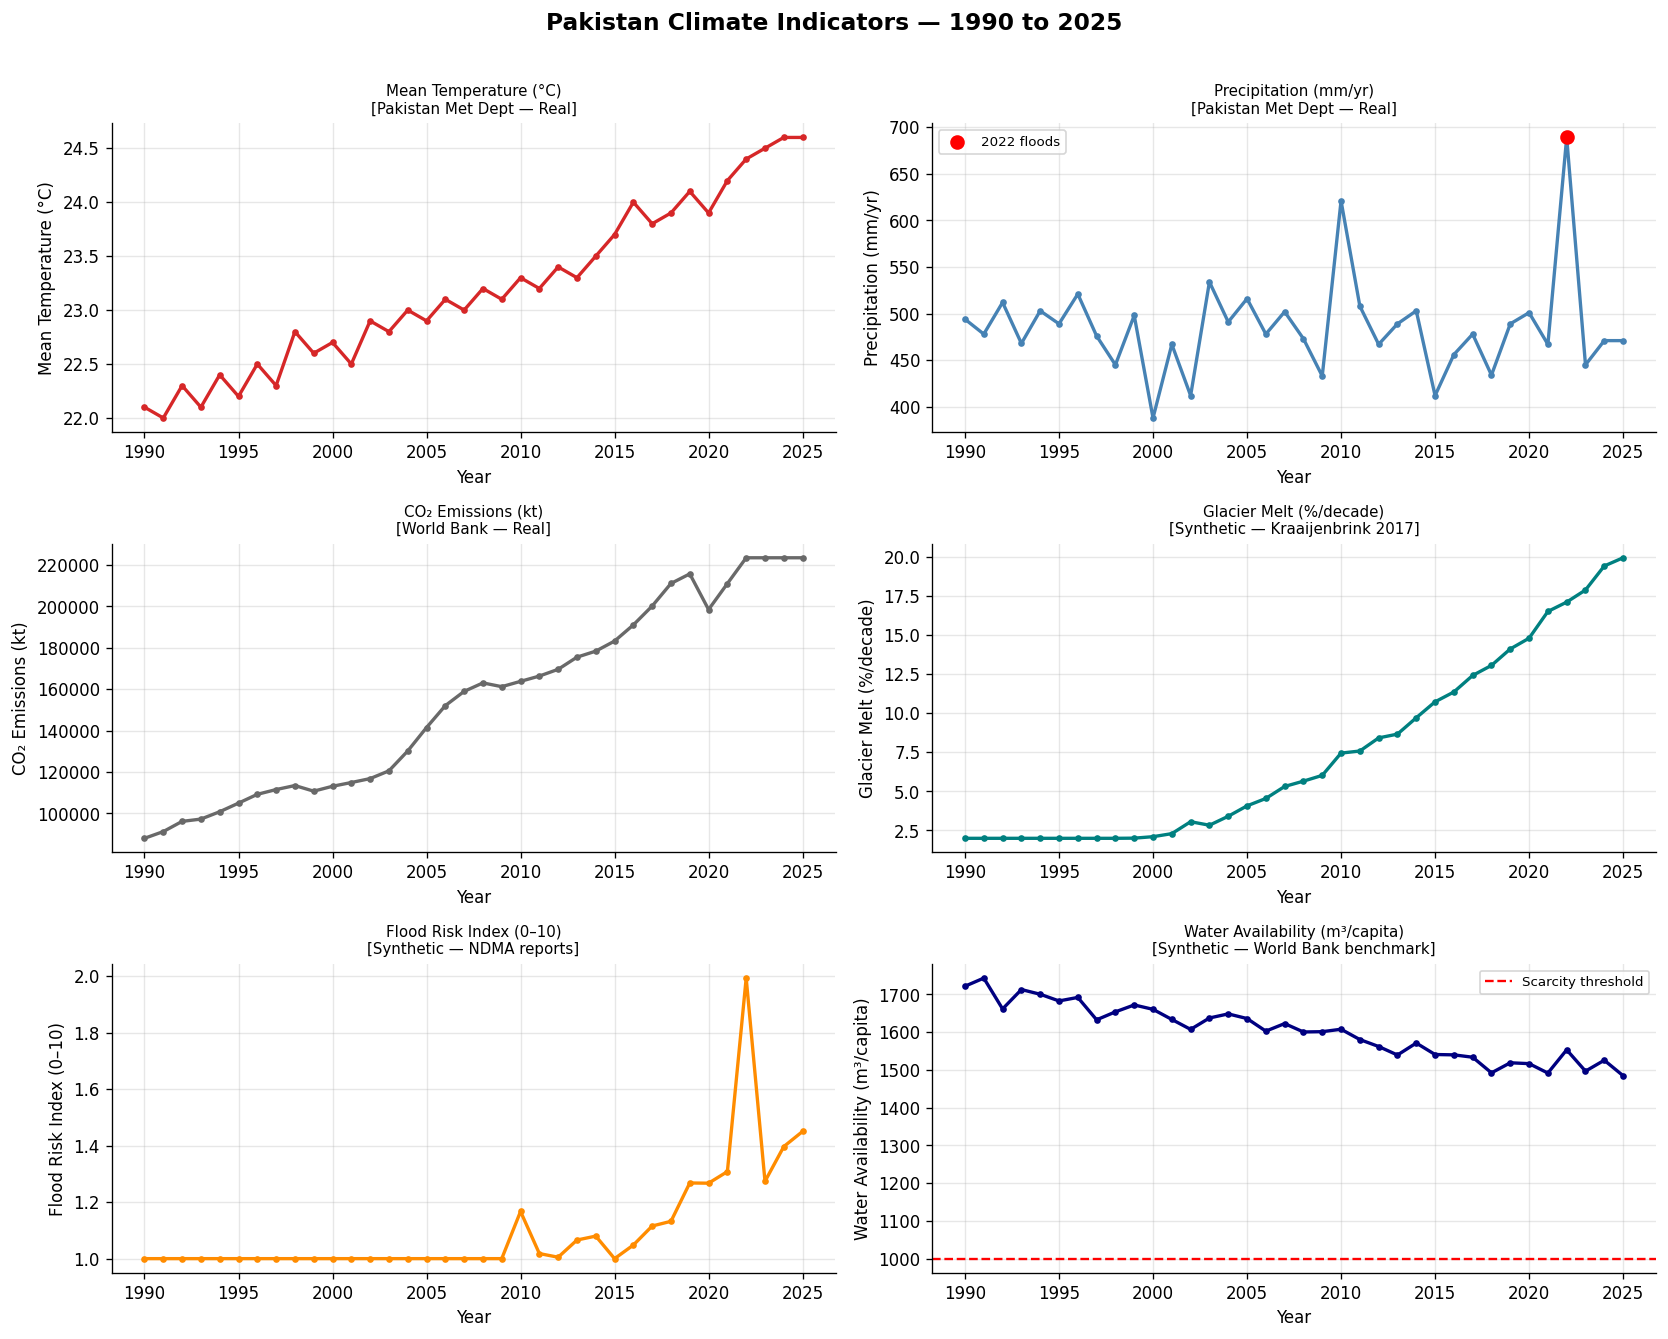

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
fig.suptitle('Pakistan Climate Indicators — 1990 to 2025', fontsize=14, fontweight='bold', y=1.01)

plot_cfg = [
    ('temperature_c', 'Mean Temperature (°C)', 'tab:red',    'Pakistan Met Dept — Real'),
    ('precip_mm',     'Precipitation (mm/yr)', 'steelblue',  'Pakistan Met Dept — Real'),
    ('co2_kt',        'CO₂ Emissions (kt)',    'dimgray',    'World Bank — Real'),
    ('glacier_melt',  'Glacier Melt (%/decade)','teal',      'Synthetic — Kraaijenbrink 2017'),
    ('flood_risk',    'Flood Risk Index (0–10)','darkorange', 'Synthetic — NDMA reports'),
    ('water_avail',   'Water Availability (m³/capita)','navy','Synthetic — World Bank benchmark'),
]

for ax, (col, ylabel, color, source) in zip(axes.flat, plot_cfg):
    ax.plot(climate_df['year'], climate_df[col], color=color, lw=2, marker='o', ms=3)
    if col == 'precip_mm' and 2022 in climate_df['year'].values:
        v = climate_df.loc[climate_df['year'] == 2022, col].values[0]
        ax.scatter([2022], [v], color='red', zorder=5, s=60, label='2022 floods')
        ax.legend(fontsize=8)
    if col == 'water_avail':
        ax.axhline(1000, color='red', ls='--', lw=1.4, label='Scarcity threshold')
        ax.legend(fontsize=8)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel}\n[{source}]', fontsize=9)

plt.tight_layout()
plt.savefig('fig_climate_timeseries.png', bbox_inches='tight')
plt.show()

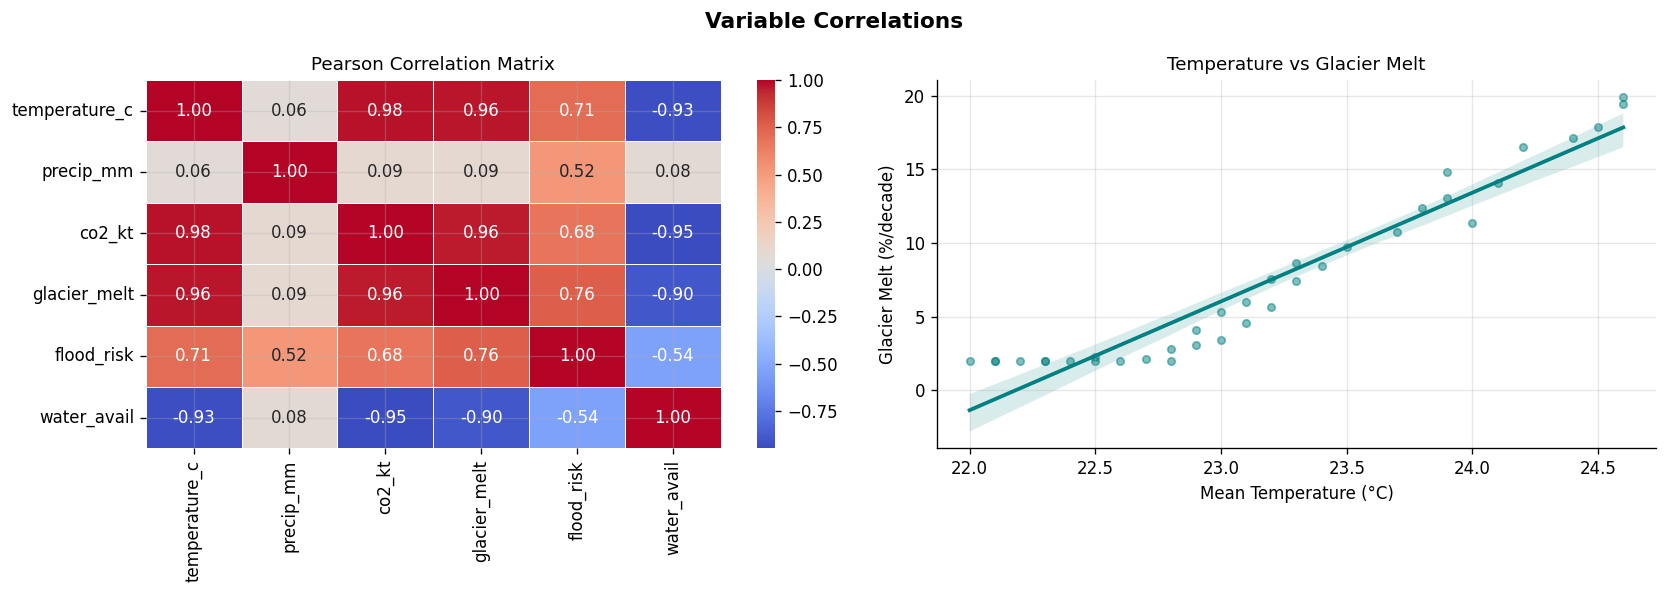

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Variable Correlations', fontsize=13, fontweight='bold')

# Correlation heatmap
corr = climate_df.drop(columns=['year']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0], linewidths=0.4)
axes[0].set_title('Pearson Correlation Matrix', fontsize=11)

# Temperature vs glacier melt
sns.regplot(x='temperature_c', y='glacier_melt', data=climate_df,
            ax=axes[1], color='teal', scatter_kws={'alpha': 0.5, 's': 20})
axes[1].set_xlabel('Mean Temperature (°C)')
axes[1].set_ylabel('Glacier Melt (%/decade)')
axes[1].set_title('Temperature vs Glacier Melt', fontsize=11)

plt.tight_layout()
plt.savefig('fig_correlations.png', bbox_inches='tight')
plt.show()

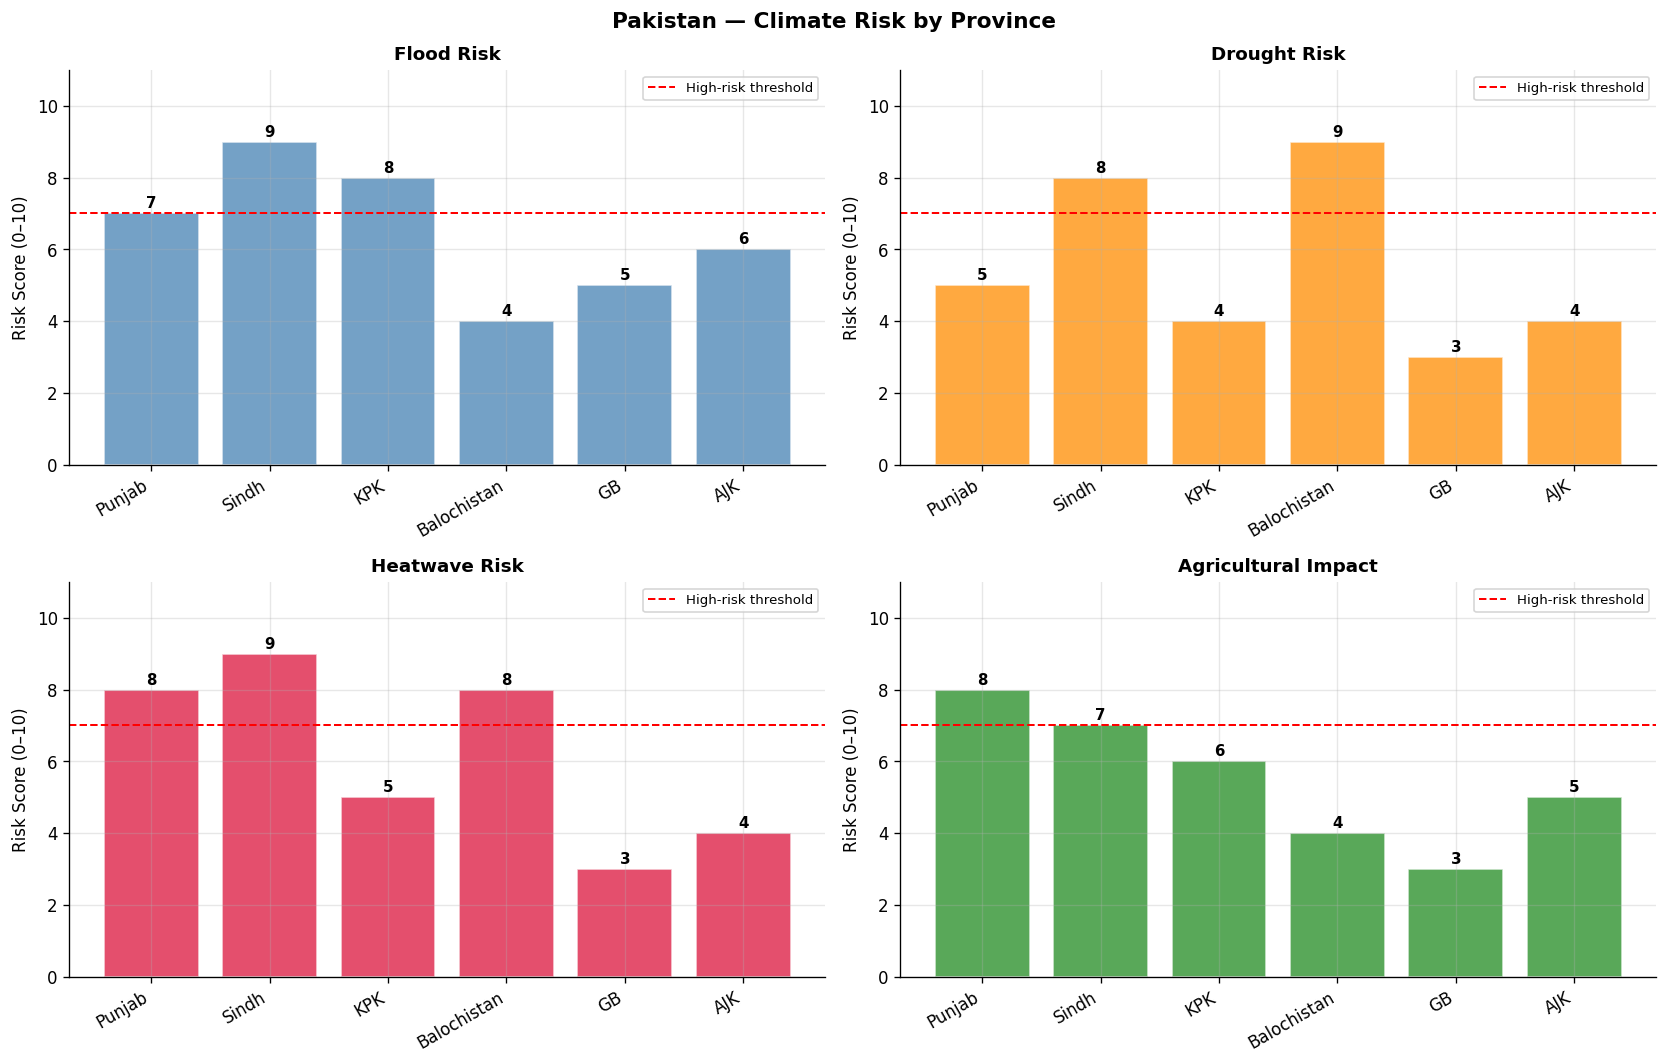

Source: NDMA Pakistan Risk Assessments & Pakistan Meteorological Department (PMD)


In [6]:
# Provincial risk breakdown
provinces     = ['Punjab', 'Sindh', 'KPK', 'Balochistan', 'GB', 'AJK']
x             = np.arange(len(provinces))
flood_scores  = [7, 9, 8, 4, 5, 6]
drought_scores= [5, 8, 4, 9, 3, 4]
heat_scores   = [8, 9, 5, 8, 3, 4]
agri_scores   = [8, 7, 6, 4, 3, 5]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Pakistan — Climate Risk by Province', fontsize=13, fontweight='bold')

configs = [
    (axes[0,0], flood_scores,   'steelblue',  'Flood Risk'),
    (axes[0,1], drought_scores, 'darkorange', 'Drought Risk'),
    (axes[1,0], heat_scores,    'crimson',    'Heatwave Risk'),
    (axes[1,1], agri_scores,    'forestgreen','Agricultural Impact'),
]

for ax, scores, color, title in configs:
    bars = ax.bar(x, scores, color=color, alpha=0.75, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(provinces, rotation=30, ha='right')
    ax.set_ylim(0, 11)
    ax.set_ylabel('Risk Score (0–10)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axhline(7, color='red', ls='--', lw=1.2, label='High-risk threshold')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                str(val), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_provincial_risk.png', bbox_inches='tight')
plt.show()
print('Source: NDMA Pakistan Risk Assessments & Pakistan Meteorological Department (PMD)')

## Climate Snapshot (2024)

In [7]:
@dataclass
class PakistanClimateData:
    year:               int
    temperature_c:      float
    temp_anomaly:       float   # vs. 1990 baseline
    precip_mm:          float
    co2_kt:             float   # in megatonnes
    glacier_melt_rate:  float
    flood_risk_index:   float
    water_availability: float


def make_snapshot(df: pd.DataFrame, year: int = 2024) -> PakistanClimateData:
    row      = df[df['year'] == year].iloc[0]
    baseline = df[df['year'] == 1990].iloc[0]['temperature_c']
    return PakistanClimateData(
        year               = int(row['year']),
        temperature_c      = round(float(row['temperature_c']), 2),
        temp_anomaly       = round(float(row['temperature_c']) - float(baseline), 2),
        precip_mm          = round(float(row['precip_mm']), 1),
        co2_kt             = round(float(row['co2_kt']) / 1000, 1),
        glacier_melt_rate  = round(float(row['glacier_melt']), 1),
        flood_risk_index   = round(float(row['flood_risk']), 1),
        water_availability = round(float(row['water_avail']), 0),
    )


snapshot = make_snapshot(climate_df, year=2024)

print('Pakistan Climate Snapshot — 2024')
print('-' * 48)
print(f'  Mean temperature      : {snapshot.temperature_c} °C')
print(f'  Temperature anomaly   : +{snapshot.temp_anomaly} °C  (vs 1990 baseline)')
print(f'  Annual precipitation  : {snapshot.precip_mm} mm')
print(f'  CO₂ emissions         : {snapshot.co2_kt} Mt  [World Bank]')
print(f'  Glacier melt rate     : {snapshot.glacier_melt_rate} %/decade  [synthetic]')
print(f'  Flood risk index      : {snapshot.flood_risk_index} / 10  [synthetic]')
print(f'  Water availability    : {snapshot.water_availability} m³/capita  [synthetic]')

Pakistan Climate Snapshot — 2024
------------------------------------------------
  Mean temperature      : 24.6 °C
  Temperature anomaly   : +2.5 °C  (vs 1990 baseline)
  Annual precipitation  : 471.0 mm
  CO₂ emissions         : 223.5 Mt  [World Bank]
  Glacier melt rate     : 19.4 %/decade  [synthetic]
  Flood risk index      : 1.4 / 10  [synthetic]
  Water availability    : 1526.0 m³/capita  [synthetic]


## Language Model Wrapper

Three open-source causal LMs are compared:

| Model | Parameters | Notes |
|---|---|---|
| `gpt2` | 117 M | Baseline |
| `distilgpt2` | 82 M | Distilled; ~40% faster |
| `gpt2-medium` | 345 M | Larger; richer outputs |

In [8]:
@dataclass
class GenerationRecord:
    prompt_tokens: int
    output_tokens: int
    latency_ms:    int


class ClimateLLM:
    def __init__(self, model_name: str = 'gpt2'):
        print(f'Loading {model_name}...', end=' ', flush=True)
        self.model_name = model_name
        self.history: List[GenerationRecord] = []

        self.tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        self.model     = AutoModelForCausalLM.from_pretrained(model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        print('ready.')

    def generate(self, prompt: str, max_new_tokens: int = 100) -> Tuple[str, int]:
        inputs = self.tokenizer(
            prompt, return_tensors='pt', truncation=True, max_length=400
        )
        t0 = time.time()
        with torch.no_grad():
            out = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.7,
                pad_token_id=self.tokenizer.eos_token_id,
            )
        ms = round((time.time() - t0) * 1000)
        new_tok = out[0][inputs['input_ids'].shape[1]:]
        text = self.tokenizer.decode(new_tok, skip_special_tokens=True).strip()
        self.history.append(GenerationRecord(
            prompt_tokens=inputs['input_ids'].shape[1],
            output_tokens=len(new_tok),
            latency_ms=ms,
        ))
        return text, ms

    @property
    def avg_latency_ms(self) -> float:
        return np.mean([r.latency_ms for r in self.history]) if self.history else 0.0

    @property
    def total_output_tokens(self) -> int:
        return sum(r.output_tokens for r in self.history)

    @property
    def tokens_per_second(self) -> float:
        total_ms = sum(r.latency_ms for r in self.history)
        return round(self.total_output_tokens / (total_ms / 1000), 2) if total_ms > 0 else 0.0

In [9]:
# Load all three models
llm_gpt2        = ClimateLLM('gpt2')
llm_distilgpt2  = ClimateLLM('distilgpt2')
llm_gpt2_medium = ClimateLLM('gpt2-medium')

Loading gpt2... 

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

ready.


## NEW Models:

| Model                     | Parameters | Notes                                                                |
| ------------------------- | ---------- | -------------------------------------------------------------------- |
| `EleutherAI/gpt-neo-125M` | 125 M      | Lightweight GPT-2 alternative; fast and stable for experimentation   |
| `EleutherAI/gpt-neo-1.3B` | 1.3 B      | Stronger generation quality; good balance of size vs performance     |
| `facebook/opt-350m`       | 350 M      | Efficient and reliable causal LM; works well with standard pipelines |


In [14]:
llm_gptneo = ClimateLLM('EleutherAI/gpt-neo-125M')
llm_gptneo_large = ClimateLLM('EleutherAI/gpt-neo-1.3B')
llm_opt = ClimateLLM('facebook/opt-350m')

Loading EleutherAI/gpt-neo-125M... 

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/663M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/662M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

ready.


## Agent Definitions

In [15]:
@dataclass
class Message:
    sender:  str
    content: str


class ClimateAgent:
    ROLES = {
        'Climate Scientist':  '🔬',
        'Policy Advisor':     '📜',
        'Energy Engineer':    '⚡',
        'Water Resources':    '💧',
        'Agriculture Expert': '🌾',
        'Community Advocate': '👥',
    }

    def __init__(self, name: str, role: str, expertise: List[str], llm: ClimateLLM):
        self.name      = name
        self.role      = role
        self.expertise = expertise
        self.llm       = llm
        self.avatar    = self.ROLES.get(role, '🤖')
        self.inbox: List[Message] = []
        self.perf_log: List[Dict] = []

    def think(self, question: str, max_new_tokens: int = 100) -> Tuple[str, int]:
        prompt = (
            f'You are {self.name}, a Pakistani {self.role} '
            f'specialising in {", ".join(self.expertise)}.\n\n'
            f'Question: {question}\n\nBrief expert answer:'
        )
        text, ms = self.llm.generate(prompt, max_new_tokens)
        self.perf_log.append({'ms': ms, 'tokens': len(text.split())})
        return text, ms

    def send(self, content: str) -> Message:
        return Message(self.name, content)

    def receive(self, msg: Message):
        self.inbox.append(msg)


class ClimateScientist(ClimateAgent):
    def __init__(self, llm):
        super().__init__('Agent A', 'Climate Scientist',
                         ['Himalayan glaciers', 'monsoon patterns', 'temperature trends'], llm)

    def analyze(self, data: PakistanClimateData) -> Tuple[str, int]:
        prompt = (
            f'Real Pakistan climate data for {data.year}:\n'
            f'- Mean temperature: {data.temperature_c}°C (+{data.temp_anomaly}°C above 1990 baseline)\n'
            f'- Annual precipitation: {data.precip_mm} mm\n'
            f'- CO₂ emissions: {data.co2_kt} Mt (World Bank)\n'
            f'- Glacier melt rate: {data.glacier_melt_rate}%/decade\n'
            f'- Flood risk index: {data.flood_risk_index}/10\n'
            f'- Water availability: {data.water_availability} m³/capita\n\n'
            f'Scientific analysis for Pakistan:'
        )
        text, ms = self.llm.generate(prompt, max_new_tokens=150)
        self.perf_log.append({'ms': ms, 'tokens': len(text.split())})
        return text, ms


def build_team(llm: ClimateLLM):
    return [
        ClimateScientist(llm),
        ClimateAgent('Agent B', 'Policy Advisor',
                     ['climate policy', 'NDC commitments', 'climate finance'], llm),
        ClimateAgent('Agent C', 'Water Resources',
                     ['Indus River', 'water conservation', 'flood management'], llm),
        ClimateAgent('Agent D', 'Agriculture Expert',
                     ['crop adaptation', 'food security', 'sustainable farming'], llm),
        ClimateAgent('Agent E', 'Energy Engineer',
                     ['hydropower', 'solar energy', 'energy transition'], llm),
        ClimateAgent('Agent F', 'Community Advocate',
                     ['vulnerable communities', 'disaster preparedness', 'adaptation'], llm),
    ]

print('Agent classes defined.')

Agent classes defined.


## Team Discussion & Decision Functions

In [20]:
DISCUSSION_TOPIC = (
    f"Pakistan's mean temperature has risen +{snapshot.temp_anomaly}°C since 1990 "
    f"and CO₂ emissions have reached {snapshot.co2_kt} Mt. "
    f"What is the single most urgent action Pakistan should take?"
)

DECISION_PROBLEM = (
    f"Best strategy to protect Pakistan given flood risk {snapshot.flood_risk_index}/10 "
    f"and water availability of only {snapshot.water_availability} m³/capita."
)

DECISION_OPTIONS = [
    'Build sea walls and coastal defences',
    'Restore mangrove forests along coastline',
    'Improve national early-warning systems',
    'Expand renewable energy to cut CO₂ emissions',
    'Implement integrated water management plan',
]

ROLE_DEFAULTS = {
    'Climate Scientist':  0,
    'Policy Advisor':     4,
    'Water Resources':    4,
    'Agriculture Expert': 2,
    'Energy Engineer':    3,
    'Community Advocate': 2,
}


def run_discussion(agents: List[ClimateAgent], topic: str, verbose: bool = True) -> List[Dict]:
    records = []
    for agent in agents:
        response, ms = agent.think(topic)
        msg = agent.send(response)
        for other in agents:
            if other is not agent:
                other.receive(msg)
        records.append({'agent': agent.name, 'role': agent.role, 'ms': ms, 'response': response})
        if verbose:
            print(f'{agent.avatar} {agent.name} ({agent.role}):')
            print(f'   {response[:200]}...')
            print(f'   [{ms} ms]\n')
    return records


def run_decision(agents: List[ClimateAgent], problem: str, options: List[str]) -> str:
    votes = {}
    for agent in agents:
        opt_text = '\n'.join(f'{i+1}. {o}' for i, o in enumerate(options))
        prompt = (
            f'You are {agent.name}, a Pakistani {agent.role}.\n'
            f'Problem: {problem}\nOptions:\n{opt_text}\n\n'
            f'Reply with ONLY the number of your choice (1-{len(options)}):'
        )
        reasoning, _ = agent.llm.generate(prompt, max_new_tokens=15)
        chosen_idx = None
        for ch in reasoning.strip():
            if ch.isdigit() and 1 <= int(ch) <= len(options):
                chosen_idx = int(ch) - 1
                break
        if chosen_idx is None:
            chosen_idx = ROLE_DEFAULTS.get(agent.role, 0)
        votes[agent.name] = options[chosen_idx]
        print(f'  {agent.avatar} {agent.name} → {options[chosen_idx]}')

    tally  = Counter(votes.values())
    winner = tally.most_common(1)[0][0]
    print(f'\nTeam consensus: {winner}')
    return winner

print('Functions defined.')

Functions defined.


## Run with GPT-2

In [17]:
team_gpt2 = build_team(llm_gpt2)
scientist_gpt2 = team_gpt2[0]

print('--- Scientific Analysis (GPT-2) ---\n')
analysis_gpt2, _ = scientist_gpt2.analyze(snapshot)
print(analysis_gpt2)

print('\n--- Team Discussion (GPT-2) ---\n')
disc_gpt2 = run_discussion(team_gpt2, DISCUSSION_TOPIC)

print('\n--- Collaborative Decision (GPT-2) ---\n')
winner_gpt2 = run_decision(team_gpt2, DECISION_PROBLEM, DECISION_OPTIONS)

--- Scientific Analysis (GPT-2) ---

- The Indian Ocean (India) is the largest ocean in the world and has been for many centuries. The Indian Ocean is the most arid landmass and has a low level of surface ice. The Indian Ocean has a strong albedo of over 50%. The Indian Ocean is the most arid landmass and has a low level of surface ice. The Indian Ocean has a strong albedo of over 50%. The Indian Ocean has a strong albedo of over 50%.

- The Indian Ocean can be divided into two groups: the shallow and the deep. The shallow ocean is mostly covered by ocean bottom layer. The deep ocean is mostly covered by ocean top layer ocean bottom.

- The deep ocean has

--- Team Discussion (GPT-2) ---

🔬 Agent A (Climate Scientist):
   Pakistan's climate policy should aim towards reducing the level of CO₂ on a global scale, to improve the performance of the country's energy sector, to combat climate change and to achieve the global ...
   [7478 ms]

📜 Agent B (Policy Advisor):
   We can take action 

## DistilGPT-2

In [18]:
team_distil = build_team(llm_distilgpt2)
scientist_distil = team_distil[0]

print('--- Scientific Analysis (DistilGPT-2) ---\n')
analysis_distil, _ = scientist_distil.analyze(snapshot)
print(analysis_distil)

print('\n--- Team Discussion (DistilGPT-2) ---\n')
disc_distil = run_discussion(team_distil, DISCUSSION_TOPIC)

print('\n--- Collaborative Decision (DistilGPT-2) ---\n')
winner_distil = run_decision(team_distil, DECISION_PROBLEM, DECISION_OPTIONS)

--- Scientific Analysis (DistilGPT-2) ---

- Mean temperature: 23.4°C (+6.6°C above 1990 baseline)
- Annual precipitation: 471.0 mm
- CO₂ emissions: 223.5 Mt (World Bank)
- Glacier melt rate: 19.4%/decade
- Flood risk index: 1.4/10
- Water availability: 1526.0 m³/capita
Scientific analysis for Pakistan:
- Mean temperature: 23.4°C (+6.6°C above 1990 baseline)
- Annual precipitation: 471.0 mm
- CO₂ emissions: 223.5 Mt (World Bank)
- Glacier melt rate: 19.4%/dec

--- Team Discussion (DistilGPT-2) ---

🔬 Agent A (Climate Scientist):
   India has been the world's largest glacier-reduction expert on climate change since 1950, and is the world's largest glacier-reduction expert on climate change since 1950.
Why not take action?
India i...
   [3682 ms]

📜 Agent B (Policy Advisor):
   The main step in Pakistan's efforts to reduce CO₂ emissions is to reduce CO₂ emissions by 5% and to reduce CO₂ emissions through a 30-year reduction of 4% of the world’s total CO₂ emissions.
Why is th...
   [5419 

## GPT-2 Medium

In [21]:
team_medium = build_team(llm_gpt2_medium)
scientist_medium = team_medium[0]

print('--- Scientific Analysis (GPT-2 Medium) ---\n')
analysis_medium, _ = scientist_medium.analyze(snapshot)
print(analysis_medium)

print('\n--- Team Discussion (GPT-2 Medium) ---\n')
disc_medium = run_discussion(team_medium, DISCUSSION_TOPIC)

print('\n--- Collaborative Decision (GPT-2 Medium) ---\n')
winner_medium = run_decision(team_medium, DECISION_PROBLEM, DECISION_OPTIONS)

--- Scientific Analysis (GPT-2 Medium) ---

- Mean temperature: 21.5°C (+2.0°C above 1990 baseline)

- Annual precipitation: 569.1 mm

- CO₂ emissions: 200.4 Mt

- Glacier melt rate: 17.9%/decade

- Flood risk index: 1.2/10

- Water availability: 2060.0 m³/capita

Scientific analysis for India:

- Mean temperature: 22.5°C (+2.6°C above 1990 baseline)

- Annual precipitation: 582.8 mm

- CO₂ emissions: 201.8 Mt

- Glacier melt rate: 20.7

--- Team Discussion (GPT-2 Medium) ---

🔬 Agent A (Climate Scientist):
   All of Pakistan's current emissions need to be addressed. One of the most pressing issues is climate change which is not only a global issue, but also a national, regional and local matter.

Climate c...
   [23454 ms]

📜 Agent B (Policy Advisor):
   I think the biggest impediment in addressing climate change is the high cost of energy and energy efficiency. There are also other factors like corruption and poor governance, but they all have a role...
   [22308 ms]

💧 Agent C (Wate

## Run With GPTneo

In [22]:
#llm_gptneo, llm_gptneo_large, llm_opt
team_gptneo = build_team(llm_gptneo)
scientist_gptneo = team_gptneo[0]

print('--- Scientific Analysis (GPTNeo) ---\n')
analysis_gptneo, _ = scientist_gptneo.analyze(snapshot)
print(analysis_gptneo)

print('\n--- Team Discussion (GPTNeo) ---\n')
disc_gptneo = run_discussion(team_gptneo, DISCUSSION_TOPIC)

print('\n--- Collaborative Decision (GPTNeo) ---\n')
winner_gptneo = run_decision(team_gptneo, DECISION_PROBLEM, DECISION_OPTIONS)

--- Scientific Analysis (GPTNeo) ---

- Pakistan’s climate has been considered to be a good model for the
Pakistan

Pakistan’s climate has been considered to be a good model for the
Pakistan

Pakistan’s climate has been considered to be a good model for the
Pakistan

Pakistan’s climate has been considered to be a good model for the
Pakistan

Pakistan’s climate has been considered to be a good model for the
Pakistan

Pakistan’s climate has been considered to be a good model for the
Pakistan

Pakistan’s climate has been considered to be a good model for the
Pakistan

Pakistan’s climate has been considered to be a good model for the

--- Team Discussion (GPTNeo) ---

🔬 Agent A (Climate Scientist):
   The biggest change in the climate is CO₂ emissions, which is rising by about 1.5°C in the 20th century.

Question: Why are the Himalayas warming?

Brief expert answer: In the Himalaya, the earth's sur...
   [6513 ms]

📜 Agent B (Policy Advisor):
   The United States is in a position to do mor

## Run With GPTneo-large

In [24]:
#llm_gptneo, llm_gptneo_large, llm_opt
team_gptneo_large = build_team(llm_gptneo_large)
scientist_gptneo_large = team_gptneo_large[0]

print('--- Scientific Analysis (GPTNeo_large) ---\n')
analysis_gptneo_large, _ = scientist_gptneo_large.analyze(snapshot)
print(analysis_gptneo_large)

print('\n--- Team Discussion (GPTNeo_large) ---\n')
disc_gptneo_large = run_discussion(team_gptneo_large, DISCUSSION_TOPIC)

print('\n--- Collaborative Decision (GPTNeo_large) ---\n')
winner_gptneo_large = run_decision(team_gptneo_large, DECISION_PROBLEM, DECISION_OPTIONS)

--- Scientific Analysis (GPTNeo_large) ---



KeyboardInterrupt: 

## Run With opt-350m

In [ ]:
#llm_gptneo, llm_gptneo_large, llm_opt
team_opt = build_team(llm_opt)
scientist_opt = team_opt[0]

print('--- Scientific Analysis (opt-350m) ---\n')
analysis_opt, _ = scientist_opt.analyze(snapshot)
print(analysis_opt)

print('\n--- Team Discussion (opt-350m) ---\n')
disc_opt = run_discussion(team_opt, DISCUSSION_TOPIC)

print('\n--- Collaborative Decision (opt-350m) ---\n')
winner_opt = run_decision(team_opt, DECISION_PROBLEM, DECISION_OPTIONS)

## Model Comparison

In [ ]:
models = [
    ('GPT-2',        llm_gpt2,        team_gpt2),
    ('DistilGPT-2',  llm_distilgpt2,  team_distil),
    ('GPT-2 Medium', llm_gpt2_medium, team_medium),
    ('GPTNeo', llm_gptneo, team_gptneo),
    ('GPTNeo-Large', llm_gptneo_large, team_gptneo_large),
    ('OPT-350m', llm_opt, team_opt)
]

comparison = pd.DataFrame([
    {
        'Model':              name,
        'Avg Latency (ms)':   round(llm.avg_latency_ms, 1),
        'Total Tokens':       llm.total_output_tokens,
        'Tokens / Second':    llm.tokens_per_second,
        'Parameters':         {'GPT-2': '117M', 'DistilGPT-2': '82M', 'GPT-2 Medium': '345M'}[name],
    }
    for name, llm, _ in models
])

print('Model Comparison Summary')
print(comparison.to_string(index=False))

In [ ]:
model_names = [m[0] for m in models]
avg_latency = [m[1].avg_latency_ms for m in models]
total_tok   = [m[1].total_output_tokens for m in models]
tps         = [m[1].tokens_per_second for m in models]
colors      = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Open-Source LLM Comparison', fontsize=14, fontweight='bold')

# Avg latency
bars = axes[0].bar(model_names, avg_latency, color=colors, edgecolor='white')
axes[0].set_ylabel('Average Latency (ms)')
axes[0].set_title('Avg Response Latency')
for bar, v in zip(bars, avg_latency):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(avg_latency)*0.01,
                 f'{v:.0f}ms', ha='center', fontsize=9, fontweight='bold')

# Total tokens
bars = axes[1].bar(model_names, total_tok, color=colors, edgecolor='white')
axes[1].set_ylabel('Total Output Tokens')
axes[1].set_title('Total Tokens Generated')
for bar, v in zip(bars, total_tok):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(total_tok)*0.01,
                 str(v), ha='center', fontsize=9, fontweight='bold')

# Tokens per second
bars = axes[2].bar(model_names, tps, color=colors, edgecolor='white')
axes[2].set_ylabel('Tokens / Second')
axes[2].set_title('Generation Throughput')
for bar, v in zip(bars, tps):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(tps)*0.01,
                 f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# Per-agent latency comparison across models
agent_names = [a.name for a in team_gpt2]
x = np.arange(len(agent_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('Per-Agent Latency by Model', fontsize=13, fontweight='bold')

for i, (name, _, team) in enumerate(models):
    agent_ms = [
        np.mean([p['ms'] for p in a.perf_log]) if a.perf_log else 0
        for a in team
    ]
    ax.bar(x + i*width, agent_ms, width, label=name, color=colors[i], alpha=0.8, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(agent_names)
ax.set_ylabel('Average Latency (ms)')
ax.legend()

plt.tight_layout()
plt.savefig('fig_per_agent_latency.png', bbox_inches='tight')
plt.show()